# Parameter-Based Curve Reconstruction (Leave-One-Out)

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).

This work is based on the research paper: *"Hysteresis Phenomenon in the Electric Parameters of Lithium-Ion Batteries under Temperature Effects"* (Barcellona et al., THERMINIC 2025).

### Dataset Overview
* **Scope:** 5 Epochs (aging states) × 8 Temperatures × 5 SOC levels.
* **Total Data:** 40 unique Nyquist plots.
* **Objective:** Perform a **Leave-One-Out** cross-validation by excluding one specific *Epoch × Temperature* combination. The goal is to train models on the remaining 39 combinations to accurately predict the 40th (unseen) plot.

---

### Project Pipeline
1. **Data Conversion:** Automated transformation from raw MATLAB files (`.mat`) to structured CSV format.
2. **EDA (Exploratory Data Analysis):** Visualizing impedance trends across different temperatures and aging stages.
3. **Leave-One-Out Setup:** Manual or randomized selection of the test set (the "excluded" combination).
4. **Feature Engineering:** Extracting and scaling relevant physical parameters for the ML models.
5. **Multi-Model Benchmarking:** Training and testing 6 different regression models.
6. **Model Selection:** Identifying the best-performing architecture based on error metrics (MAE, RMSE).
7. **Hyperparameter Tuning:** Fine-tuning the best model to improve reconstruction accuracy.
8. **Error Analysis:** Detailed evaluation of residuals and physical consistency of the predictions.
9. **Grid Reconstruction:** Final 40/40 visualization to validate the global performance of the approach.

---

# 1. Setup

In [1]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd
import scipy.io

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
    ExtraTreesRegressor
)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#666666",
}

EPOCH_LABELS = {
    0: "Epoch 0 (Fresh)",
    1: "Epoch 1",
    2: "Epoch 2",
    3: "Epoch 3",
    4: "Epoch 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

TEMPS_SORTED = sorted(TEMP_COLORS.keys())
EPOCHS = list(EPOCH_LABELS.keys())

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )


print_environment_info()

Setup completed
Python 3.12 | NumPy 2.0.1 | Pandas 2.3.3 | Scikit-learn 1.7.1


# 2. Caricamento e Conversione Dati

In [2]:
# --- LOAD MATLAB FILE ---

import os
import scipy.io
import pandas as pd
from pathlib import Path

# --- ROBUST PATH HANDLING ---
try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path(os.getcwd())

# If the notebook is inside the 'notebooks' folder, move up to project root
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

# Full path to the MAT file
file_path = project_root / "data" / "raw" / "GEIS.mat"

print(f"Looking for file at: {file_path}")

# --- LOAD FILE ---
if not file_path.exists():
    raise FileNotFoundError(f"GEIS.mat file not found at: {file_path}")

mat_data = scipy.io.loadmat(
    str(file_path),
    squeeze_me=True,
    struct_as_record=False
)

# --- TEMPERATURE MAPPING ---
TEMP_KEYS = {
    "GEIS_20": 20.0,
    "GEIS_22_5": 22.5,
    "GEIS_25": 25.0,
    "GEIS_27_5": 27.5,
    "GEIS_30": 30.0,
    "GEIS_35": 35.0,
    "GEIS_40": 40.0,
    "GEIS_47_5": 47.5,
}

# --- DATA EXTRACTION ---
def extract_records(mat_data, temp_keys, num_epochs=5):
    records = []

    for epoch in range(num_epochs):
        aging_key = f"Aging{epoch}"
        aging_struct = getattr(mat_data, aging_key, mat_data.get(aging_key))

        for temp_key, temperature in temp_keys.items():
            temp_data = getattr(aging_struct, temp_key)

            for soc_idx, soc_data in enumerate(temp_data):
                for row in soc_data:
                    records.append({
                        "Epoch": epoch,
                        "Temperature": temperature,
                        "SOC": soc_idx,
                        "Frequency": row[0],
                        "Z_real": row[1] * 1000,   # mΩ
                        "Z_imag": row[2] * 1000,   # mΩ
                    })

    return pd.DataFrame(records)

# --- CREATE DATAFRAME ---
df = extract_records(mat_data, TEMP_KEYS)

# --- SAVE DATASET ---
output_file = "../data/processed/batteries_cleaned_dataset.csv"
df.to_csv(output_file, index=False)

# --- SUMMARY ---
def print_dataset_summary(df):
    print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(
        f"Epochs: {sorted(df['Epoch'].unique())} | "
        f"Temperatures: {sorted(df['Temperature'].unique())} °C"
    )
    print(
        f"SOC levels: {sorted(df['SOC'].unique())} | "
        f"Frequency range: {df['Frequency'].min():.2f}–{df['Frequency'].max():.0f} Hz"
    )
    print(
        f"Epoch × Temperature combinations: "
        f"{df.groupby(['Epoch', 'Temperature']).ngroups}"
    )

# Preview
df.head(10)

Looking for file at: /Users/marcosoldani/Desktop/SUPSI/terzo_anno/secondo_semestre/batterie_elettriche/ml_LiBs_project/data/raw/GEIS.mat


,Epoch,Temperature,SOC,Frequency,Z_real,Z_imag
0,0,20.0,0,10002.2290,3.004527,-0.916100
1,0,20.0,0,7904.9590,2.971508,-0.661783
2,0,20.0,0,6248.7827,3.047303,-0.422141
3,0,20.0,0,4941.5811,3.100461,-0.164312
4,0,20.0,0,3906.2498,3.172908,-0.012017
5,0,20.0,0,3087.0369,3.247350,0.125193
6,0,20.0,0,2440.7808,3.340029,0.239525
7,0,20.0,0,1930.6177,3.418471,0.317611
8,0,20.0,0,1525.4882,3.508611,0.390777
9,0,20.0,0,1206.9312,3.598584,0.455021


# 3. Analisi Esplorativa dei Dati (EDA)

In [3]:
# 3.1 Descriptive statistics
print("=== DESCRIPTIVE STATISTICS ===\n")
print(df.describe().round(4).to_string())

=== DESCRIPTIVE STATISTICS ===

           Epoch  Temperature        SOC   Frequency     Z_real     Z_imag
count  9805.0000    9805.0000  9805.0000   9805.0000  9805.0000  9805.0000
mean      2.0010      30.9319     2.0000    974.0061     4.1713     0.3392
std       1.4146       8.7461     1.4143   2119.3246     1.5224     0.3910
min       0.0000      20.0000     0.0000      0.0999     1.6747    -1.3053
25%       1.0000      22.5000     1.0000      2.1230     3.0491     0.1436
50%       2.0000      27.5000     2.0000     35.5575     3.8333     0.2858
75%       3.0000      35.0000     3.0000    596.7186     4.9928     0.5070
max       4.0000      47.5000     4.0000  10002.2290    13.0745     2.6160


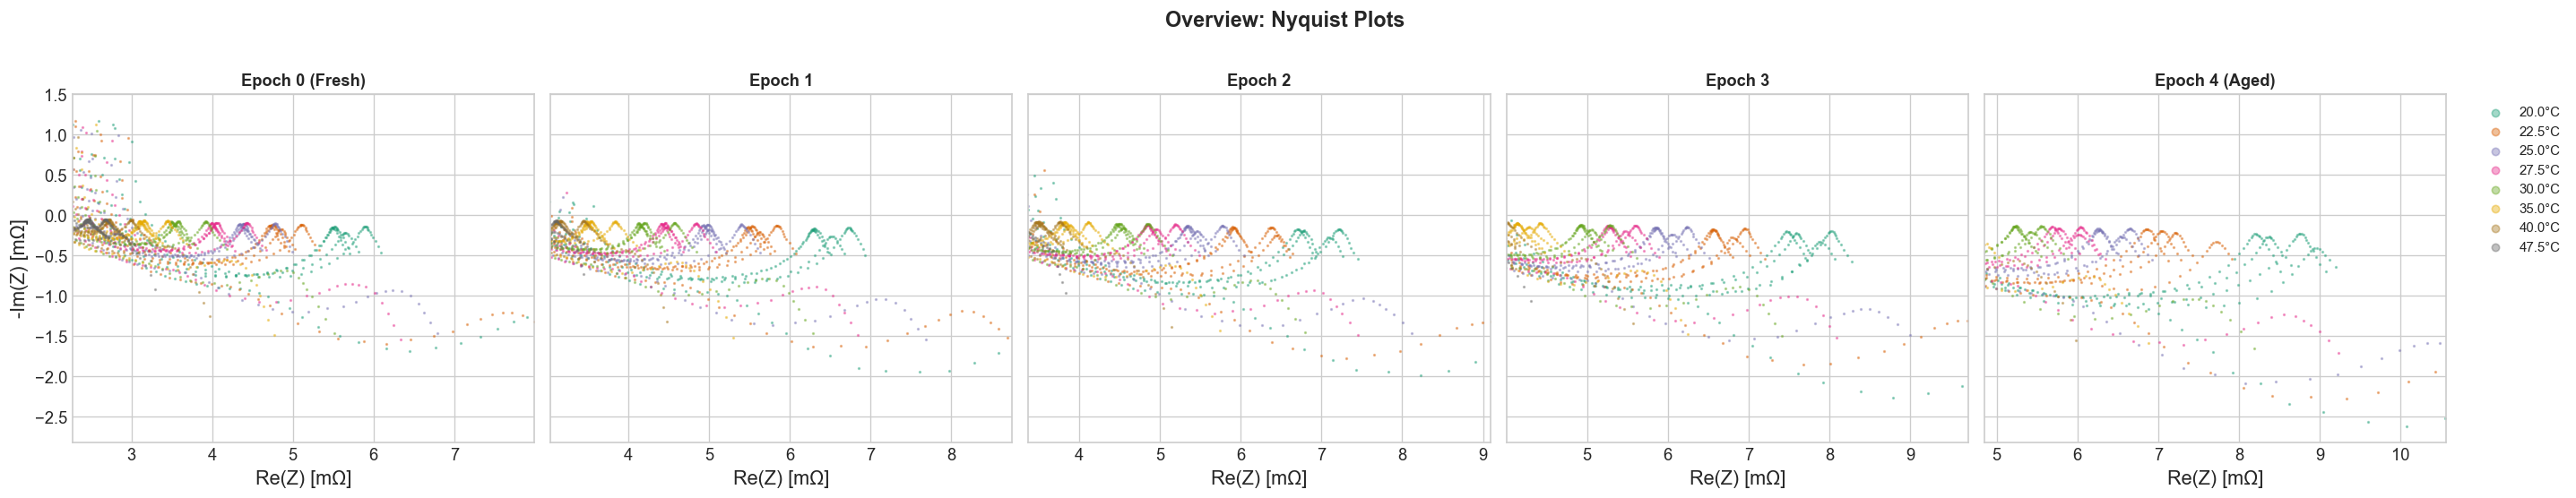

In [4]:
# 3.2 Nyquist plot overview by Epoch and Temperature
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for epoch in range(5):
    ax = axes[epoch]
    subset = df[df["Epoch"] == epoch]

    for temp in TEMPS_SORTED:
        mask = subset["Temperature"] == temp
        ax.scatter(
            subset.loc[mask, "Z_real"],
            -subset.loc[mask, "Z_imag"],
            s=1,
            alpha=0.4,
            color=TEMP_COLORS[temp],
            label=f"{temp}°C"
        )

    ax.set_xlabel("Re(Z) [mΩ]")
    
    if epoch == 0:
        ax.set_ylabel("-Im(Z) [mΩ]")

    ax.set_title(EPOCH_LABELS[epoch], fontsize=11, fontweight="bold")
    ax.set_aspect("equal", adjustable="datalim")

# Legend and title
axes[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=5,
    fontsize=9
)

fig.suptitle(
    "Overview: Nyquist Plots",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

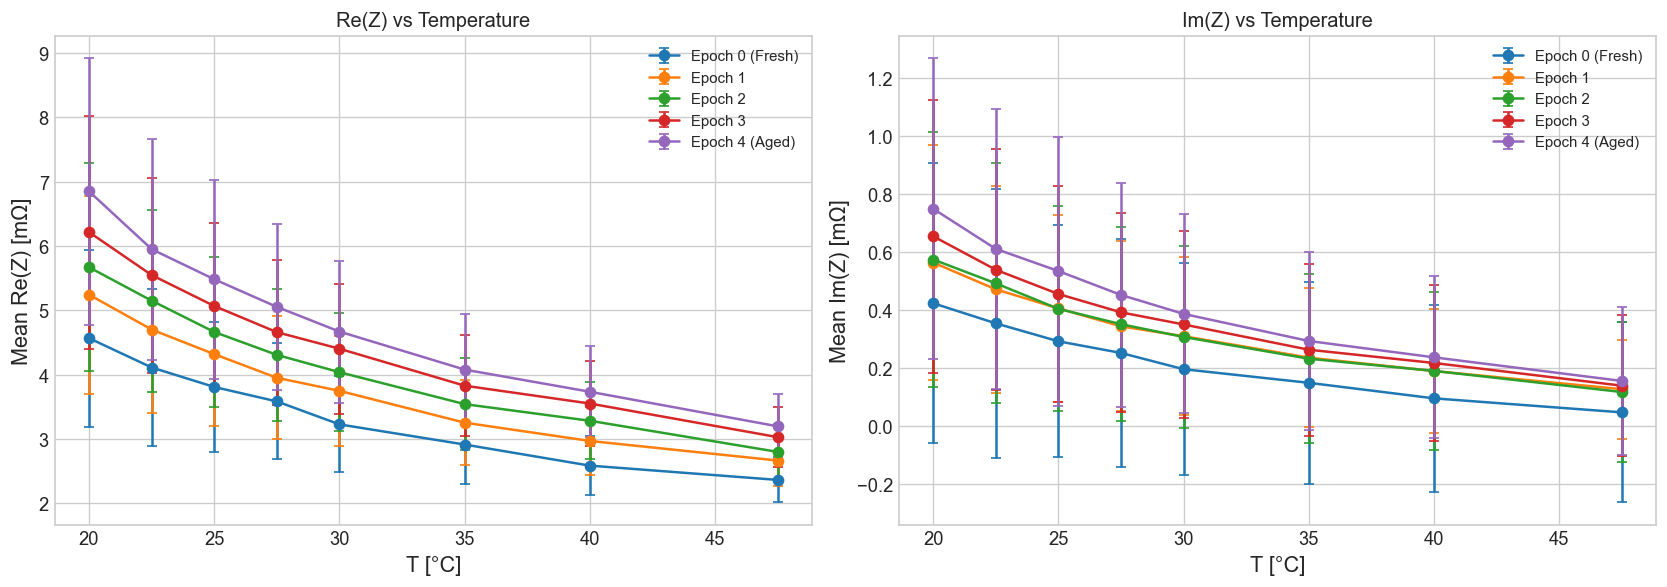

In [5]:
# 3.3 Impedance vs Temperature trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for epoch in range(5):
    subset = df[df["Epoch"] == epoch]

    for ax_idx, (col, label) in enumerate([("Z_real", "Re(Z)"), ("Z_imag", "Im(Z)")]):
        means = subset.groupby("Temperature")[col].mean()
        stds = subset.groupby("Temperature")[col].std()

        axes[ax_idx].errorbar(
            means.index,
            means.values,
            yerr=stds.values,
            marker="o",
            label=EPOCH_LABELS[epoch],
            capsize=3
        )

# Axis configuration
axes[0].set_xlabel("T [°C]")
axes[0].set_ylabel("Mean Re(Z) [mΩ]")
axes[0].set_title("Re(Z) vs Temperature")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("T [°C]")
axes[1].set_ylabel("Mean Im(Z) [mΩ]")
axes[1].set_title("Im(Z) vs Temperature")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()